In [47]:
# 7-9-2026

In [48]:
# thios iteration, im making the mlp modular

In [82]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [83]:
transfer_matrix = pd.read_csv("../transfer-matrix/rf_transfer_matrix.csv")
transfer_matrix.set_index("Unnamed: 0", inplace=True)
transfer_matrix.index.name = None
transfer_matrix.index = transfer_matrix.index.astype(int)
transfer_matrix.columns = transfer_matrix.columns.astype(int)
transfer_matrix

,0,1,2,4,5,6,7,8,11,12,...,32,33,36,37,38,39,45,46,47,49
0,0.392727,0.291660,0.127238,0.058840,0.214817,0.084705,0.149056,0.182358,0.173877,0.026375,...,0.228505,0.243433,0.149609,0.275203,0.112525,-0.011557,0.116862,0.158796,0.025454,0.029928
1,0.142172,0.395760,0.030643,0.010376,0.180707,0.064432,0.056092,0.128808,0.097788,0.039590,...,0.167477,0.032806,0.029704,0.193033,0.055264,0.066550,0.108203,0.199762,0.023240,-0.037710
2,0.196600,0.214445,0.368173,0.023968,0.207323,0.140139,0.172990,0.231019,0.156741,0.057226,...,0.197402,0.223793,0.121457,0.248807,0.134485,0.053503,-0.005610,0.253965,0.031899,0.059566
4,0.235489,0.227173,0.127394,0.410382,0.215954,0.186207,0.125068,0.196603,0.165264,0.034514,...,0.178055,0.245668,0.147579,0.284360,0.217076,-0.003941,0.037643,0.306750,0.137154,0.020968
5,0.190803,0.206530,0.097887,0.087230,0.464604,0.144950,0.159361,0.204884,0.264641,0.104493,...,0.197195,0.232923,0.117228,0.292623,0.170687,-0.020694,0.115293,0.297271,0.067951,0.051770
6,0.178282,0.238235,0.034447,0.220869,0.191487,0.317381,0.118250,0.163631,0.119401,0.021430,...,0.202794,0.247076,0.125801,0.255555,0.201974,-0.068777,0.099243,0.321076,0.102840,-0.017236
7,0.113396,0.054282,0.061550,0.069370,0.044484,0.109329,0.329688,0.092023,0.159883,0.051387,...,0.184071,0.179713,0.142222,0.192045,0.209176,0.035736,0.042035,0.159817,0.008022,0.022467
8,0.181002,0.228547,-0.006209,0.023346,0.133774,0.117255,0.194411,0.424899,0.064289,-0.004919,...,0.093679,0.136592,0.101116,0.173933,0.095452,-0.003312,0.050942,0.240088,0.051530,0.007182
11,0.214508,0.227264,0.109767,0.124790,0.237549,0.076848,0.107019,0.207917,0.551275,-0.003236,...,0.256072,0.166287,0.102690,0.366209,0.181682,-0.007782,0.147501,0.206234,-0.057620,0.064859
12,0.118927,0.175802,-0.016922,0.112255,0.159920,0.070012,0.077276,0.026258,0.103184,0.502334,...,0.163311,-0.091433,0.060118,0.163172,0.119053,0.080449,0.089125,0.118189,0.068853,-0.070408


In [84]:
descriptors = pd.read_csv("../encoder-inputs/domain_descriptions.csv")
descriptors.set_index("domain_id", inplace=True)
descriptors.index = descriptors.index.astype(int)
descriptors.head()

,vpd_mean,vpd_std,vpd_p90,ws10_mean,ws10_std,ws10_p90,t2m_max_mean,t2m_max_std,t2m_max_p90,ndvi_mean,...,swvl4_p90,gwis_ba_mean,gwis_ba_std,gwis_ba_p90,cams_frpfire_mean,cams_frpfire_std,cams_frpfire_p90,fire_sparsity,land_cover_diversity,fire_season_length
domain_id,,,,,,,,,,,,,,,,,,,,,
0,11.229313,5.895861,19.746270,2.516127,1.052111,3.968697,302.43317,4.790887,307.46002,0.641714,...,0.479085,547.38410,1932.2546,1112.03370,0.067789,0.469590,0.097816,0.081824,0.728328,6
1,6.742952,3.144529,10.522034,1.406203,0.511182,2.132592,301.80650,4.735351,305.51370,0.796118,...,0.499585,338.66165,1157.0903,705.89197,0.063071,0.392797,0.108795,0.013560,0.218936,7
2,21.599873,10.565010,36.654785,4.066474,0.951055,5.291819,303.89624,6.380806,311.61792,0.242577,...,0.257699,3360.49340,8181.0723,8625.16300,0.162555,0.925012,0.219152,0.032987,0.602900,7
3,4.211150,2.716757,7.958644,3.166607,1.505368,5.099028,286.08792,10.954839,299.41890,0.550528,...,0.411259,328.76685,739.6544,901.44635,0.041860,0.274789,0.000000,0.001419,0.365885,3
4,2.564834,3.033652,6.938553,3.300411,1.380530,5.114551,273.42078,16.251247,293.80110,0.315671,...,0.447848,669.05206,2307.7700,1315.65490,0.185203,1.571907,0.090595,0.007227,0.615066,5


In [85]:
descriptors.columns
# atmospheric conditions: 'vpd_mean', 'vpd_std', 'vpd_p90', 'ws10_mean', 'ws10_std', 'ws10_p90', 't2m_max_mean', 't2m_max_std', 't2m_max_p90', 'tp_mean', 'tp_std', 'tp_p90'
# ground conditions: 'ndvi_mean', 'ndvi_std', 'ndvi_p90', 'swvl1_mean', 'swvl1_std', 'swvl1_p90', 'swvl4_mean', 'swvl4_std', 'swvl4_p90', 'land_cover_diversity'
# fire characteristics: 'fwi_mean_mean', 'fwi_mean_std', 'fwi_mean_p90', 'gwis_ba_mean', 'gwis_ba_std','gwis_ba_p90', 'cams_frpfire_mean', 'cams_frpfire_std', 'cams_frpfire_p90', 'fire_sparsity', 'fire_season_length'

Index(['vpd_mean', 'vpd_std', 'vpd_p90', 'ws10_mean', 'ws10_std', 'ws10_p90',
       't2m_max_mean', 't2m_max_std', 't2m_max_p90', 'ndvi_mean', 'ndvi_std',
       'ndvi_p90', 'tp_mean', 'tp_std', 'tp_p90', 'fwi_mean_mean',
       'fwi_mean_std', 'fwi_mean_p90', 'swvl1_mean', 'swvl1_std', 'swvl1_p90',
       'swvl4_mean', 'swvl4_std', 'swvl4_p90', 'gwis_ba_mean', 'gwis_ba_std',
       'gwis_ba_p90', 'cams_frpfire_mean', 'cams_frpfire_std',
       'cams_frpfire_p90', 'fire_sparsity', 'land_cover_diversity',
       'fire_season_length'],
      dtype='object')

In [86]:
# sanity check
print(transfer_matrix.shape)   # should be (34, 34)
print(descriptors.shape)       # should be (34, 33)
print(transfer_matrix.index.tolist())
print(descriptors.index.tolist())

(34, 34)
(50, 33)
[0, 1, 2, 4, 5, 6, 7, 8, 11, 12, 13, 16, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 32, 33, 36, 37, 38, 39, 45, 46, 47, 49]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]


In [87]:
active_ids = transfer_matrix.index.tolist()
descriptors_active = descriptors.loc[active_ids]

In [88]:
# these ar tesintng domains and train domains
holdout_ids = [45, 46, 47, 49]
train_ids = [d for d in active_ids if d not in holdout_ids]

In [89]:
# fit scaler on train descriptors only, transform all 34
scaler = StandardScaler()
train_desc = descriptors_active.loc[train_ids]
scaler.fit(train_desc)

StandardScaler()

In [90]:
desc_scaled = pd.DataFrame(
    scaler.transform(descriptors_active),
    index=descriptors_active.index,
    columns=descriptors_active.columns
)

In [91]:
atmospheric_cols = ["vpd_mean", "vpd_std", "vpd_p90", "ws10_mean", "ws10_std", "ws10_p90", "t2m_max_mean", "t2m_max_std", "t2m_max_p90", "tp_mean", "tp_std", "tp_p90"]

ground_cols = ["ndvi_mean", "ndvi_std", "ndvi_p90", "swvl1_mean", "swvl1_std", "swvl1_p90", "swvl4_mean", "swvl4_std", "swvl4_p90", "land_cover_diversity"]

fire_cols = ["fwi_mean_mean", "fwi_mean_std", "fwi_mean_p90", "gwis_ba_mean", "gwis_ba_std", "gwis_ba_p90", "cams_frpfire_mean", "cams_frpfire_std", "cams_frpfire_p90", "fire_sparsity", "fire_season_length"]

In [92]:
atmospheric_idx = [desc_scaled.columns.get_loc(c) for c in atmospheric_cols]
ground_idx = [desc_scaled.columns.get_loc(c) for c in ground_cols]
fire_idx = [desc_scaled.columns.get_loc(c) for c in fire_cols]

In [93]:
ground_idx

[9, 10, 11, 18, 19, 20, 21, 22, 23, 31]

In [94]:
# sanity check: train columns should have mean ~0 and std ~1
train_check = desc_scaled.loc[train_ids]
print(train_check.mean().round(6).unique())  # should be all ~0
print(train_check.std().round(6).unique())   # should be all ~1

[-0.]
[1.017095]


In [95]:
# generate ordered pairs
def make_pairs(id_list, matrix):
    pairs = []
    for i in id_list:
        for j in id_list:
            t_ij = matrix.loc[i, j]
            pairs.append((i, j, t_ij))
    return pairs

train_pairs = make_pairs(train_ids, transfer_matrix)

In [96]:
# test pairs are any pair where at least one domain in holdout
test_pairs = []
for i in active_ids:
    for j in active_ids:
        if i in holdout_ids or j in holdout_ids:
            test_pairs.append((i, j, transfer_matrix.loc[i, j]))

In [97]:
print(f"train pairs: {len(train_pairs)}")  # should be 900
print(f"test pairs: {len(test_pairs)}")    # should be 34*34 - 30*30 = 256

train pairs: 900
test pairs: 256


In [98]:
class TransferDataset(Dataset):
    def __init__(self, pairs, desc_scaled):
        self.pairs = pairs
        self.desc = desc_scaled

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        i, j, t_ij = self.pairs[idx]
        desc_i = torch.tensor(self.desc.loc[i].values, dtype=torch.float32)
        desc_j = torch.tensor(self.desc.loc[j].values, dtype=torch.float32)
        target = torch.tensor(t_ij, dtype=torch.float32)
        return desc_i, desc_j, target

In [99]:
g = torch.Generator()
g.manual_seed(5)

train_dataset = TransferDataset(train_pairs, desc_scaled)
test_dataset = TransferDataset(test_pairs, desc_scaled)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [100]:
# grab one batch
desc_i, desc_j, target = next(iter(train_loader))
print(desc_i.shape) # 64, 33
print(desc_j.shape) # 64, 33
print(target.shape) # 64

torch.Size([64, 33])
torch.Size([64, 33])
torch.Size([64])


In [101]:
class ModularEncoder(nn.Module):
    def __init__(self, atmospheric_idx, ground_idx, fire_idx, branch_embed_dim=3, dropout=0.2):
        super().__init__()
        self.atmospheric_idx = atmospheric_idx
        self.ground_idx = ground_idx
        self.fire_idx = fire_idx

        self.atmospheric_branch = self._make_branch(len(atmospheric_idx), branch_embed_dim, dropout)
        self.ground_branch = self._make_branch(len(ground_idx), branch_embed_dim, dropout)
        self.fire_branch = self._make_branch(len(fire_idx), branch_embed_dim, dropout)

    def _make_branch(self, input_dim, embed_dim, dropout): # private
        return nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, embed_dim)
        ) # one branch, now input-16-16-3

    def forward(self, x):
        x_atm = x[:, self.atmospheric_idx]
        x_ground = x[:, self.ground_idx]
        x_fire = x[:, self.fire_idx]

        e_atm = self.atmospheric_branch(x_atm)
        e_ground = self.ground_branch(x_ground)
        e_fire = self.fire_branch(x_fire)

        return torch.cat([e_atm, e_ground, e_fire], dim=-1)

In [102]:
class PredictionHead(nn.Module):
    def __init__(self, embed_dim=9):
        super().__init__()
        # input is [e_i, e_j, e_i - e_j], outputs spearman pred
        self.net = nn.Sequential(
            nn.Linear(embed_dim * 3, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        ) # 24-16-1

    def forward(self, e_i, e_j):
        diff = e_i - e_j
        x = torch.cat([e_i, e_j, diff], dim=-1)
        return self.net(x).squeeze(-1)

In [103]:
class TransferModel(nn.Module):
    def __init__(self, atmospheric_idx, ground_idx, fire_idx, branch_embed_dim=3):
        super().__init__()
        self.encoder = ModularEncoder(atmospheric_idx, ground_idx, fire_idx, branch_embed_dim)
        embed_dim = branch_embed_dim * 3
        self.head = PredictionHead(embed_dim)

    def forward(self, desc_i, desc_j):
        e_i = self.encoder(desc_i)
        e_j = self.encoder(desc_j)
        return self.head(e_i, e_j)

In [112]:
torch.manual_seed(5)
np.random.seed(5)
device = torch.device("cpu")
model = TransferModel(atmospheric_idx, ground_idx, fire_idx).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
loss_fn = nn.MSELoss()
NUM_EPOCHS = 150

# track losses per epoch for plotting later
train_losses = []
test_losses = []

In [114]:
import copy

best_test_loss = float("inf")
best_epoch = -1
best_state = None
patience = 40
epochs_since_improve = 0

for epoch in range(NUM_EPOCHS):
    # training
    model.train()
    train_loss = 0
    train_mae = 0
    for desc_i, desc_j, target in train_loader:
        desc_i, desc_j, target = desc_i.to(device), desc_j.to(device), target.to(device)
        optimizer.zero_grad()
        pred = model(desc_i, desc_j)
        loss = loss_fn(pred, target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(target)
        train_mae += torch.abs(pred - target).sum().item()
    train_loss /= len(train_dataset)
    train_mae /= len(train_dataset)

    # eval
    model.eval()
    test_loss = 0
    test_mae = 0
    with torch.no_grad():
        for desc_i, desc_j, target in test_loader:
            desc_i, desc_j, target = desc_i.to(device), desc_j.to(device), target.to(device)
            pred = model(desc_i, desc_j)
            test_loss += loss_fn(pred, target).item() * len(target)
            test_mae += torch.abs(pred - target).sum().item()
    test_loss /= len(test_dataset)
    test_mae /= len(test_dataset)

    # save losses for plotting
    train_losses.append(train_loss)
    test_losses.append(test_loss)

    # track best model by test loss
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        epochs_since_improve = 0
    else:
        epochs_since_improve += 1

    if epoch % 10 == 0:
        print(f"epoch {epoch:>3}, train mse: {train_loss:.4f}, test mse: {test_loss:.4f}, train mae: {train_mae:.4f}, test mae: {test_mae:.4f}")

    if epochs_since_improve >= patience:
        print(f"stopping early at epoch {epoch}, best test mse {best_test_loss:.4f} at epoch {best_epoch}")
        break

# load back the best checkpoint before doing anything downstream
model.load_state_dict(best_state)
print(f"loaded best model from epoch {best_epoch}, test mse {best_test_loss:.4f}")

epoch   0, train mse: 0.0044, test mse: 0.0085, train mae: 0.0491, test mae: 0.0717
epoch  10, train mse: 0.0044, test mse: 0.0085, train mae: 0.0481, test mae: 0.0716
epoch  20, train mse: 0.0043, test mse: 0.0083, train mae: 0.0472, test mae: 0.0710
epoch  30, train mse: 0.0042, test mse: 0.0085, train mae: 0.0473, test mae: 0.0724
epoch  40, train mse: 0.0041, test mse: 0.0083, train mae: 0.0477, test mae: 0.0714
epoch  50, train mse: 0.0041, test mse: 0.0083, train mae: 0.0462, test mae: 0.0709
epoch  60, train mse: 0.0042, test mse: 0.0083, train mae: 0.0479, test mae: 0.0712
epoch  70, train mse: 0.0041, test mse: 0.0084, train mae: 0.0462, test mae: 0.0717
epoch  80, train mse: 0.0041, test mse: 0.0083, train mae: 0.0466, test mae: 0.0701
epoch  90, train mse: 0.0038, test mse: 0.0087, train mae: 0.0457, test mae: 0.0732
stopping early at epoch 99, best test mse 0.0080 at epoch 59
loaded best model from epoch 59, test mse 0.0080


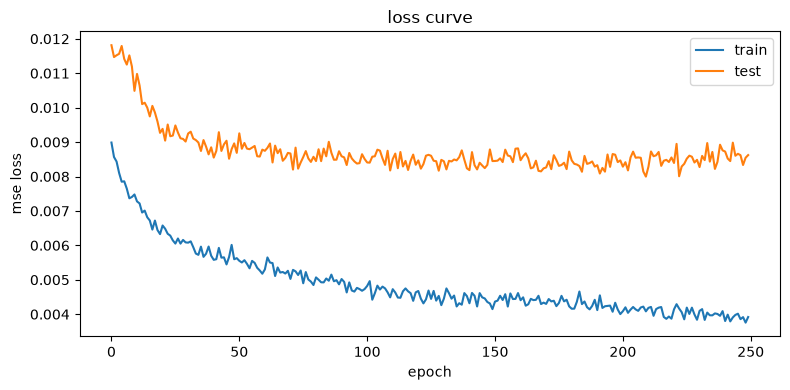

In [115]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="train")
plt.plot(test_losses, label="test")
plt.xlabel("epoch")
plt.ylabel("mse loss")
plt.title("loss curve")
plt.legend()
plt.tight_layout()
plt.show()

In [122]:
print(f"train losses: {train_losses}")
print(f"test losses: {test_losses}")

train losses: [0.008986575541396936, 0.008566030997575986, 0.008434297813413044, 0.00810228278239568, 0.007849269385139147, 0.007860256814294392, 0.007647898117494252, 0.007366884520484341, 0.007405699872308307, 0.007478507608175278, 0.007276510991052621, 0.00721802050454749, 0.006954150930460957, 0.007009975113905966, 0.006816625100457006, 0.006721515393324403, 0.006458644817272822, 0.006720293069051372, 0.0064456192942129245, 0.00632671961431495, 0.006577120075623194, 0.006483133054441876, 0.006336203174044689, 0.006282869511180454, 0.006145038165979915, 0.006052066505783134, 0.00619968644136356, 0.006050777953738967, 0.006158031357659234, 0.006086108442395925, 0.006078465702012181, 0.0061161292095979055, 0.005946409023470349, 0.005762198881970512, 0.005724442408730586, 0.0059629973427702985, 0.005666415318846703, 0.005757248020834393, 0.005965888797202044, 0.005699245467161139, 0.005579719882872369, 0.005597476114829381, 0.005926907249829835, 0.005643134125404888, 0.0056522857863456

In [123]:
torch.save(model.state_dict(), "transfer_model_v3.pt")

In [124]:
# generate all 34x34 pairs
all_pairs = [(i, j) for i in active_ids for j in active_ids]
all_targets = [transfer_matrix.loc[i, j] for i, j in all_pairs]

In [125]:
all_desc_i = torch.tensor(
    np.array([desc_scaled.loc[i].values for i, j in all_pairs]), dtype=torch.float32
).to(device)
all_desc_j = torch.tensor(
    np.array([desc_scaled.loc[j].values for i, j in all_pairs]), dtype=torch.float32
).to(device)
all_targets_tensor = torch.tensor(all_targets, dtype=torch.float32).to(device)

In [126]:
model.eval()
with torch.no_grad():
    all_preds = model(all_desc_i, all_desc_j).cpu().numpy()

all_targets_np = np.array(all_targets)

full_mae = np.abs(all_preds - all_targets_np).mean()
full_mse = ((all_preds - all_targets_np) ** 2).mean()
print(f"full matrix mae: {full_mae:.4f}")
print(f"full matrix mse: {full_mse:.4f}")

full matrix mae: 0.0473
full matrix mse: 0.0042


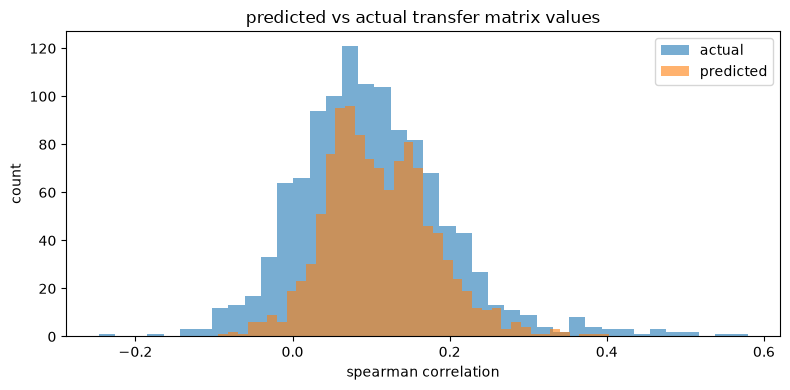

In [127]:
plt.figure(figsize=(8, 4))
plt.hist(all_targets_np, bins=40, alpha=0.6, label="actual")
plt.hist(all_preds, bins=40, alpha=0.6, label="predicted")
plt.xlabel("spearman correlation")
plt.ylabel("count")
plt.title("predicted vs actual transfer matrix values")
plt.legend()
plt.tight_layout()
plt.show()

In [128]:
pred_matrix = pd.DataFrame(
    all_preds.reshape(34, 34),
    index=active_ids,
    columns=active_ids
)
pred_matrix.shape

(34, 34)

In [129]:
pred_matrix.to_csv("predicted_transfer_matrix_v3.csv")

In [130]:
# model didn't divert to simply predicting the mean or something simple. 
# it means theres at least some signal in the transfer matrix, and can show (with futher inspection later) that different regime's patterns can be learned and mapped